In [1]:
import slangpy as spy
import pathlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = spy.create_device(
    include_paths=[
        pathlib.Path(".").absolute()
    ]
)

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


# Bitmap to Texture

Bitmap(
  pixel_format = rgb,
  component_type = uint8,
  width = 1024,
  height = 1024,
  srgb_gamma = true,
  pixel_struct = DataStruct(
    pack = true,
    byte_order = little_endian,
    fields = [
      Field(name="R", type=uint8, flags=(normalized | srgb_gamma), size=1, offset=0),
      Field(name="G", type=uint8, flags=(normalized | srgb_gamma), size=1, offset=1),
      Field(name="B", type=uint8, flags=(normalized | srgb_gamma), size=1, offset=2),
    ],
    size = 3,
    alignment = 1
  ),
  data = 3.00 MB
)


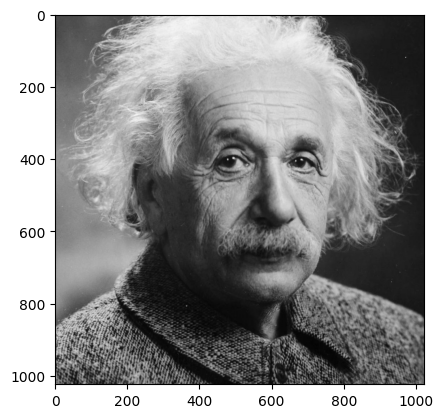

In [3]:
bmp = spy.Bitmap("albert.jpg")
print(bmp)
plt.imshow(bmp)

Bitmap(
  pixel_format = rgba,
  component_type = float32,
  width = 1024,
  height = 1024,
  srgb_gamma = true,
  pixel_struct = DataStruct(
    pack = true,
    byte_order = little_endian,
    fields = [
      Field(name="R", type=float32, flags=srgb_gamma, size=4, offset=0),
      Field(name="G", type=float32, flags=srgb_gamma, size=4, offset=4),
      Field(name="B", type=float32, flags=srgb_gamma, size=4, offset=8),
      Field(name="A", type=float32, flags=none, size=4, offset=12),
    ],
    size = 16,
    alignment = 1
  ),
  data = 16.00 MB
)


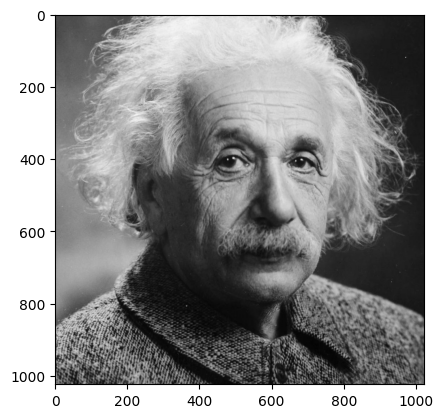

In [4]:
bmp_float = bmp.convert(
    component_type=spy.Bitmap.ComponentType.float32,
    pixel_format=spy.Bitmap.PixelFormat.rgba
)
print(bmp_float)
plt.imshow(bmp_float)

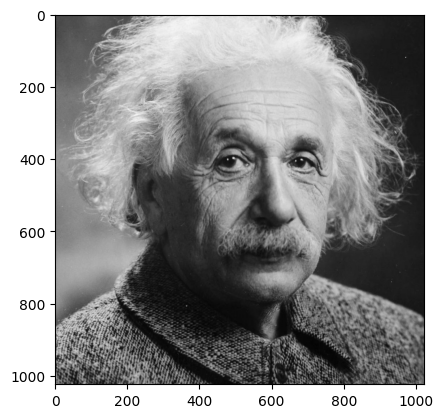

In [5]:
loader = spy.TextureLoader(device)
texture = loader.load_texture(
    bitmap=bmp_float
)
plt.imshow(texture.to_numpy()[:, :, :3])

In [6]:
print(texture.to_bitmap())

Bitmap(
  pixel_format = rgba,
  component_type = float32,
  width = 1024,
  height = 1024,
  srgb_gamma = false,
  pixel_struct = DataStruct(
    pack = true,
    byte_order = little_endian,
    fields = [
      Field(name="R", type=float32, flags=none, size=4, offset=0),
      Field(name="G", type=float32, flags=none, size=4, offset=4),
      Field(name="B", type=float32, flags=none, size=4, offset=8),
      Field(name="A", type=float32, flags=none, size=4, offset=12),
    ],
    size = 16,
    alignment = 1
  ),
  data = 16.00 MB
)


# Compute Texture

In [7]:
program = device.load_program("slang/compute-texture.slang", entry_point_names=["compute_main"])
kernel = device.create_compute_kernel(program)
kernel

ComputeKernel(0x6000000b6040)

In [8]:
size = (512, 512)
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=size[0],
    height=size[1],
    usage=spy.TextureUsage.shader_resource | spy.TextureUsage.unordered_access
)
render_target.to_numpy().shape

(512, 512, 4)

In [9]:
kernel.dispatch(
    thread_count=[size[0], size[1], 1],
    vars={
        "g_size": size,
        "g_output": render_target
    }
)

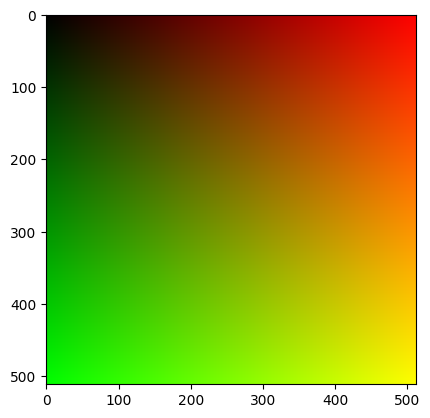

In [10]:
plt.imshow(render_target.to_bitmap())